<a href="https://colab.research.google.com/github/Smarth2005/UCS761-Deep-Learning/blob/main/notebooks/Lab-5%20MNIST%20Digit%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Lab Exercise-5
### Perform handwritten digit classification using MNIST dataset.

In [4]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [5]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
(X_train, y_train), (X_test, y_test) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

This means 60,000 images have been sampled in the training set, each of shape
 28 x 28. Similarly test set has 10,000 images of same shape.

In [8]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

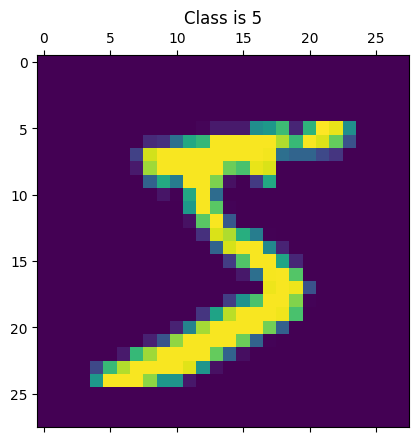

In [9]:
# Visualization
import matplotlib.pyplot as plt
plt.matshow(X_train[0])
plt.title(f"Class is {y_train[0]}")
plt.show()

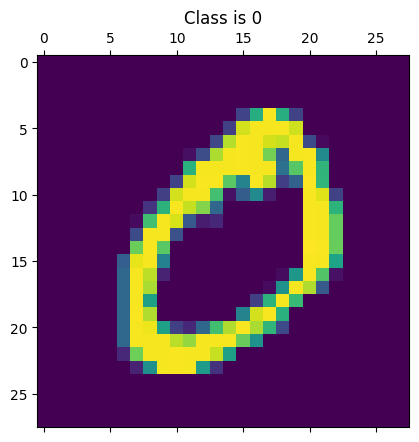

In [10]:
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [11]:
# Preprocessing
# Note: The image is interpreted in the format of pixel intensities (range: 0 to 255)

import numpy as np
np.min(X_train), np.max(X_train)


(np.uint8(0), np.uint8(255))

In [12]:
X_train = X_train/255
X_test = X_test/255

In [13]:
np.min(X_train), np.max(X_train)

(np.float64(0.0), np.float64(1.0))

In [14]:
np.min(X_test), np.max(X_test)

(np.float64(0.0), np.float64(1.0))

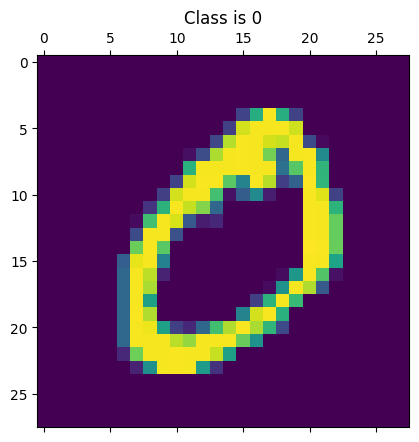

In [15]:
plt.matshow(X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [16]:
# Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu', name="h1"),
    Dropout(0.2),
    Dense(128, activation='relu', name="h2"),
    Dropout(0.2),
    Dense(64, activation='relu', name="h3"),
    Dense(10, activation='softmax') # 10 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.layers[1].get_weights() # return both weights and bias

[array([[ 0.00284658,  0.02767702, -0.0428406 , ..., -0.0455068 ,
         -0.02816546, -0.00740842],
        [ 0.0316318 , -0.03733709,  0.04036071, ..., -0.0005804 ,
         -0.05141058,  0.03612439],
        [ 0.04024101, -0.0751288 ,  0.0020653 , ..., -0.0465276 ,
          0.04989079,  0.02178581],
        ...,
        [ 0.04572552,  0.00797138,  0.02157587, ...,  0.00921053,
          0.04517825, -0.03255239],
        [ 0.03653482, -0.06924246, -0.05030474, ...,  0.01852916,
          0.03166217,  0.06288552],
        [ 0.02193402, -0.03012225,  0.04072174, ..., -0.02515274,
         -0.03063336,  0.02368914]], dtype=float32),
 array([-1.42775133e-01, -4.07508388e-02, -1.47250310e-01,  7.20872432e-02,
         3.06034670e-03,  3.93118635e-02, -3.66098881e-02, -4.76072133e-02,
         1.42608117e-03,  9.26385969e-02, -5.66708408e-02,  1.67182125e-02,
        -8.79950523e-02, -3.81582528e-02,  5.13689145e-02, -5.47609106e-03,
        -8.37636590e-02, -2.47765318e-01, -9.85730141e

In [18]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [20]:
history = model.fit(x=X_train, y=y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop]
                    )

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9174 - loss: 0.2758 - val_accuracy: 0.9623 - val_loss: 0.1199
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9607 - loss: 0.1289 - val_accuracy: 0.9739 - val_loss: 0.0815
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9697 - loss: 0.0998 - val_accuracy: 0.9741 - val_loss: 0.0806
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9743 - loss: 0.0837 - val_accuracy: 0.9756 - val_loss: 0.0790
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9780 - loss: 0.0720 - val_accuracy: 0.9764 - val_loss: 0.0846
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9789 - loss: 0.0675 - val_accuracy: 0.9779 - val_loss: 0.0760
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9821 - loss: 0.0597 - val_accuracy: 0.9811 - val_loss: 0.0675
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9827 - loss: 0.0541 -

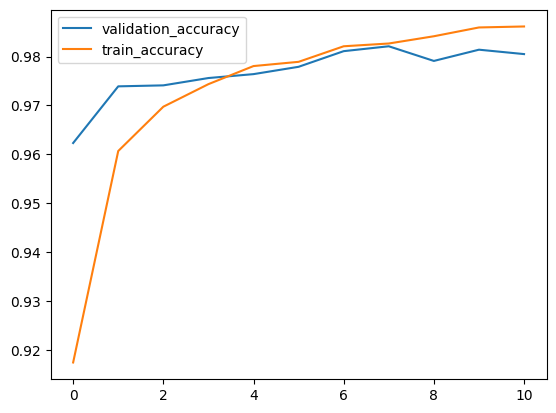

In [21]:
h = history.history

plt.plot(h['val_accuracy'], label='validation_accuracy')
plt.plot(h['accuracy'], label='train_accuracy')
plt.legend()
plt.show()

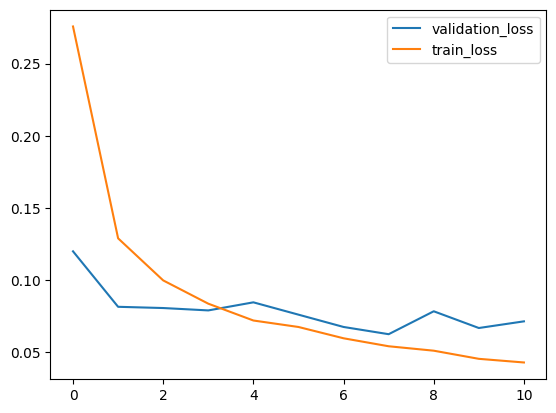

In [22]:
plt.plot(h['val_loss'], label='validation_loss')
plt.plot(h['loss'], label='train_loss')
plt.legend()
plt.show()

In [23]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0625


[0.06249796226620674, 0.9821000099182129]

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

if len(y_test.shape)>1:
  y_test = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


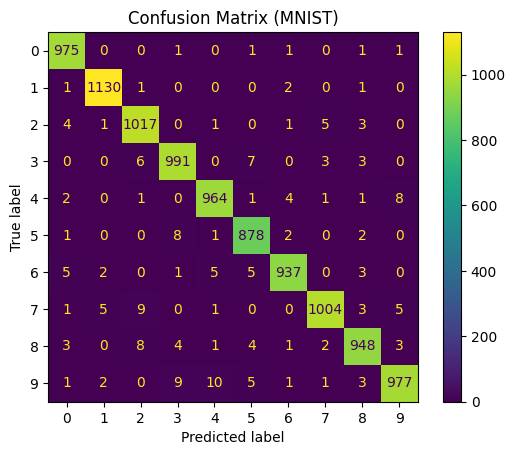

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=None)

plt.title("Confusion Matrix (MNIST)")
plt.show()